# Анализ данных в задаче кредитного скоринга

In [1]:
import statsmodels
import scipy as sc
import numpy as np
import pandas as pd
from statsmodels.stats.weightstats import zconfint
import matplotlib.pyplot as plt

In [2]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


#### Задание

Для выполнения этого задания вам понадобятся данные о кредитных историях клиентов одного из банков. Поля в предоставляемых данных имеют следующий смысл: 

LIMIT_BAL:  размер кредитного лимита (в том числе и на семью клиента)

SEX: пол клиента (1 = мужской, 2 = женский )

EDUCATION: образование (0 = доктор, 1 = магистр; 2 = бакалавр; 3 = выпускник школы; 4 = начальное образование; 5= прочее; 6 = нет данных ).

MARRIAGE: (0 = отказываюсь отвечать; 1 = замужем/женат; 2 = холост; 3 = нет данных). 

AGE: возраст в годах

PAY_0 - PAY_6 : История прошлых платежей по кредиту. PAY_6 - платеж в апреле, ... Pay_0 - платеж в сентябре. Платеж = (0 = исправный платеж, 1=задержка в один месяц, 2=задержка в 2 месяца ...)

BILL_AMT1 - BILL_AMT6:  задолженность,  BILL_AMT6 - на апрель, BILL_AMT1 - на сентябрь 

PAY_AMT1 - PAY_AMT6: сумма уплаченная в PAY_AMT6 - апреле, ..., PAY_AMT1 - сентябре 

default - индикатор невозврата денежных средств

#### Исходные данные

In [3]:
data = pd.read_csv('credit_card_default_analysis.csv', sep = ',', header = 0)
data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,0,0,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,0,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,0,0,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,0,0,0,0,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,0,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,0,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


#### Review criteria

1. Выполнение каждого пункта задания должно начинаться с графика с данными, которые вы собираетесь анализировать. Еще лучше, если вы разложите графики анализируемого фактора по переменной (default), на которую хотите изучить влияние этого фактора, и проинтерпретируете отличия в полученных распределениях.

2. При использовании статистических критериев необходимо убедиться в том, что условия их применимости выполняются. Например, если вы видите, что данные бинарные, то не нужно применять критерий Стьюдента.

3. При каждом использовании любого критерия необходимо указать, какая проверяется гипотеза, против какой альтернативы, чему равен достигаемый уровень значимости, принимается или отвергается нулевая гипотеза на уровне значимости 0.05. Если задача позволяет, нужно оценить размер эффекта и предположить, имеет ли этот результат практическую значимость. 

#### 1

Размер кредитного лимита (LIMIT_BAL). В двух группах, тех людей, кто вернул кредит (default = 0) и тех, кто его не вернул (default = 1) проверьте гипотезы:   a)  о равенстве медианных значений кредитного лимита с помощью подходящей интервальной оценки  b) о равенстве распределений с помощью одного из подходящих непараметрических критериев проверки равенства средних.  Значимы ли полученные результаты с практической точки зрения ?

In [4]:
# количественное распределение людей на тех, кто вернул кредит и тех, кто не вернул
print(data.default.value_counts())

0    23364
1     6636
Name: default, dtype: int64


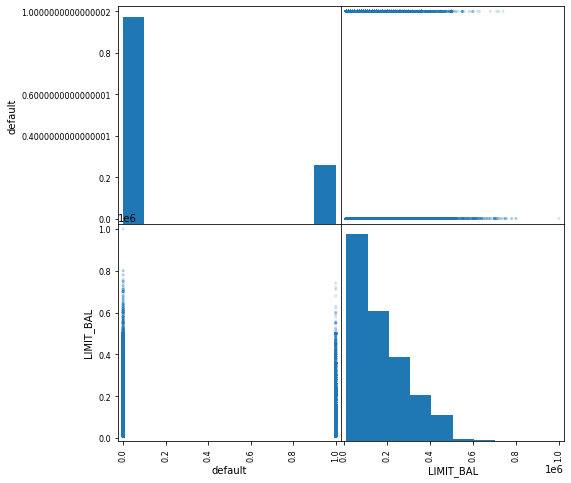

In [5]:
# матрица диаграмм рассеяния по признакам 
pd.plotting.scatter_matrix(data[['default', 'LIMIT_BAL']], alpha=0.2, figsize=(8, 8), diagonal='hist')
pylab.show()

In [6]:
# делим исходные данные на две группы
data1_def0 = data[data['default'] == 0]['LIMIT_BAL']
data1_def1 = data[data['default'] == 1]['LIMIT_BAL']

In [7]:
# точечные значения медиан
print(f'Точечное медианное значение по плательщикам: {data1_def0.median()}')
print(f'Точечное медианное значение по НЕплательщикам: {data1_def1.median()}')

Точечное медианное значение по плательщикам: 150000.0
Точечное медианное значение по НЕплательщикам: 90000.0


Похоже, медианы различаются довольно существенно. Попробуем сделать интервальную оценку медианных значений с помощью бутстрапа.

In [18]:
# используем функции из ноутбука 1-й недели курса
def get_bootstrap_samples(data, n_samples):
    indices = np.random.randint(0, len(data), (n_samples, len(data)))
    samples = data[indices]
    return samples

def stat_intervals(stat, alpha):
    boundaries = np.percentile(stat, [100 * alpha / 2., 100 * (1 - alpha / 2.)])
    return boundaries

In [23]:
np.random.seed(0)

def0_median_scores = list(map(np.median, get_bootstrap_samples(data1_def0.values, 1000)))
def1_median_scores = list(map(np.median, get_bootstrap_samples(data1_def1.values, 1000)))

print("95% доверительный интервал для медианы группы плательщиков:",  stat_intervals(def0_median_scores, 0.05))
print("95% доверительный интервал для медианы группы НЕплательщиков:",  stat_intervals(def1_median_scores, 0.05))

95% доверительный интервал для медианы группы плательщиков: [150000. 150000.]
95% доверительный интервал для медианы группы НЕплательщиков: [80000. 90000.]


_____________________
#### Выводы:
Доверительные интервалы медиан не пересекаются.

Медианные значения кредитного лимита для двух групп различны на уровне значимости 0.05.

(более того, они различны даже на уровне значимости 0.005)
_________

Проверим теперь гипотезу о равенстве распределений. Для этого посмотрим на графики распределений.

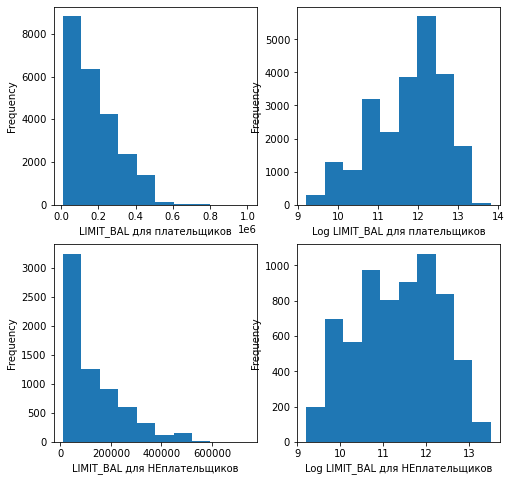

In [24]:
# графики распределений LIMIT_BAL для двух групп - обычные и логарифмические
plt.figure(figsize(8,8))
plt.subplot(221)
data1_def0.plot.hist()
plt.xlabel('LIMIT_BAL для плательщиков', fontsize=10)

plt.subplot(222)
np.log(data1_def0).plot.hist()
plt.xlabel('Log LIMIT_BAL для плательщиков', fontsize=10)

plt.subplot(223)
data1_def1.plot.hist()
plt.xlabel('LIMIT_BAL для НЕплательщиков', fontsize=10)

plt.subplot(224)
np.log(data1_def1).plot.hist()
plt.xlabel('Log LIMIT_BAL для НЕплательщиков', fontsize=10)
pylab.show()

Распределение, в принципе, неизвестно. Следует использовать непараметрические двухвыборочные критерии для независимых выборок (будем считать, что группы плательщиков и неплательщиков не пересекаются).

Используем критерий Манна-Уитни.

Нулевая гипотеза: средние значения LIMIT_BAL в двух выборках (плательщики и неплательщики) равны.

Двусторонняя альтернатива: средние значения LIMIT_BAL в двух выборках отличаются.

In [27]:
sc.stats.mannwhitneyu(data1_def0, data1_def1, alternative='two-sided')

MannwhitneyuResult(statistic=95786286.5, pvalue=1.2255485818223303e-189)

__________________________
#### Выводы:
Достигаемый уровень значимости (pvalue) практически равен нулю.

На уровне значимости 0.05 нулевая гипотеза уверенно отвергается, т.е. средние двух выборок не равны.

Практическая значимость результата имеется - клиенты банка, получившие больший кредитный лимит, вероятнее всего, выплатят кредит, а неплательщиками окажутся клиенты с меньшим кредитным лимитом.
______________________

#### 2

Пол (SEX): Проверьте гипотезу о том,  что гендерный состав  группы людей вернувших и не вернувших кредит отличается.  Хорошо, если вы предоставите несколько различных решений  этой задачи (с помощью доверительного интервала и подходящего статистического критерия)

#### 3

Образование (EDUCATION): Проверьте гипотезу о том, что образование не влияет на то, вернет ли человек долг.  Предложите способ наглядного представления разницы в ожидаемых и наблюдаемых значениях количества человек вернувших и не вернувших долг. Например, составьте таблицу сопряженности "образование" на "возврат долга", где значением ячейки была бы  разность между наблюдаемым и ожидаемым количеством человек.  Как бы вы предложили модифицировать таблицу так, чтобы привести значения ячеек к одному масштабу не потеряв в интерпретируемости ?  Наличие какого образования является наилучшим индикатором того, что человек  отдаст долг ? наоборт, не отдаст долг ?

#### 4

Семейное положение (MARRIAGE): Проверьте, как связан семейный статус с индикатором дефолта: нужно предложить меру, по которой можно измерить возможную связь этих переменных и посчитать ее значение.

#### 5

Возраст (AGE): Относительно двух групп людей  вернувших и не вернувших кредит  проверьте следующие гипотезы:   a)  о равенстве медианных значений возрастов людей   b) о равенстве распределений  с помощью одного из подходящих непараметрических критериев проверки равенства средних.  Значимы ли полученные результаты с практической точки зрения ?